In [5]:
from datasets import load_dataset
import pandas as pd
import numpy as np 
from tensorflow.keras.utils import to_categorical
from PIL import Image
import io

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import  

# Paths
TRAIN_DIR = "FER-2013/train"
TEST_DIR  = "FER-2013/test"

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    subset="validation"
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical"
)

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train samples: 22968


In [6]:
ds = load_dataset("FER-2013")
print(ds)

Resolving data files:   0%|          | 0/28709 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7178 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 28709
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 7178
    })
})


In [14]:
def ds_to_arrays(split):
    imgs, labs = [], []
    for ex in ds[split]:
        img = ex["image"]  # already a PIL image, no need for BytesIO
        img = img.convert("L").resize((48, 48))
        imgs.append(np.array(img, dtype="float32"))
        labs.append(ex["label"])  # not "labels"
    X = np.stack(imgs, axis=0)
    X = X[..., np.newaxis] / 255.0
    y = to_categorical(labs, num_classes=7)
    return X, y

In [16]:
X_train, y_train = ds_to_arrays("train")
X_val, y_val = ds_to_arrays("test")

print("Train:", X_train.shape, y_train.shape)
print("Val: ", X_val.shape, y_val.shape)

Train: (28709, 48, 48, 1) (28709, 7)
Val:  (7178, 48, 48, 1) (7178, 7)


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 10,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

datagen.fit(X_train)

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dropout,
    Flatten, Dense, BatchNormalization
)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/deepface-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,935 (2.37 MB)

 Trainable params: 619,975 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
#Train Model
epochs = 30
batch_size = 64

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    steps_per_epoch=len(X_train)//batch_size,
    validation_data = (X_val, y_val),
    epochs = epochs
)

Epoch 1/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.2598 - loss: 2.1200 - val_accuracy: 0.2690 - val_loss: 1.9621
Epoch 2/30
  1/448 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.3594 - loss: 1.6535

/opt/anaconda3/envs/deepface-env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3594 - loss: 1.6535 - val_accuracy: 0.2718 - val_loss: 1.9781
Epoch 3/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.3595 - loss: 1.6485 - val_accuracy: 0.3137 - val_loss: 2.0087
Epoch 4/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4062 - loss: 1.4939 - val_accuracy: 0.3207 - val_loss: 1.9596
Epoch 5/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4124 - loss: 1.5154 - val_accuracy: 0.4765 - val_loss: 1.3633
Epoch 6/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4375 - loss: 1.4304 - val_accuracy: 0.4804 - val_loss: 1.3581
Epoch 7/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.4436 - loss: 1.4421 - val_accuracy: 0.4369 - val_loss: 1.5131
Epoch 8/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5469 - loss: 1.3700 - val_accuracy: 0.4452 - val_loss: 1.4874
Epoch 9/30
448/448 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4590 - loss: 1.4020 - val_accuracy: 0.482

Validation loss: 1.144847
Validation accuracy: 0.571190


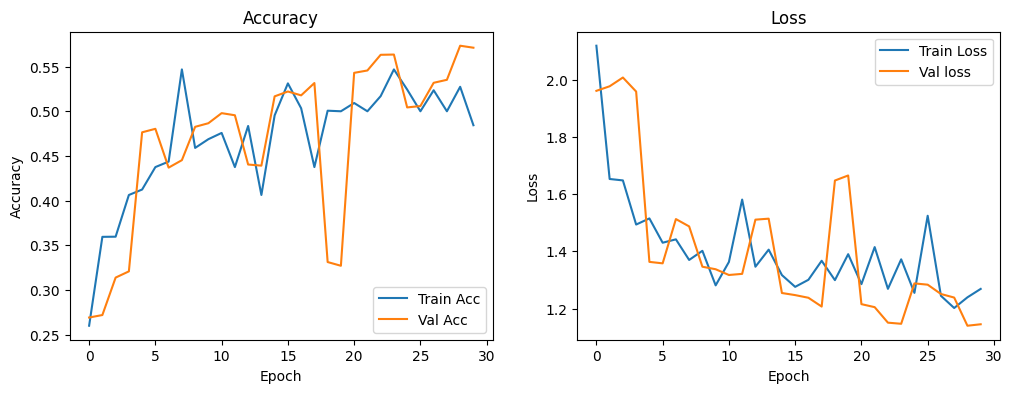

In [28]:
import matplotlib.pyplot as plt

#Final evaluation on the validation set
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation loss: {loss:4f}")
print(f"Validation accuracy: {accuracy:4f}")

#Plot training curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show() 

In [26]:
#Quick Inference on Validation Samples
import numpy as np

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

#Predict and display 5 random samples
for _ in range(5):
    idx = np.random.randint(0, X_val.shape[0])
    sample = X_val[idx:idx+1]
    pred = model.predict(sample)
    label = emotion_labels[np.argmax(pred)]
    true = emotion_labels[np.argmax(y_val[idx:idx+1])]
    print(f'True: {true:>8} - Predicted: {label:>8}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
True:      Sad - Predicted:      Sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
True:  Neutral - Predicted:  Neutral
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
True:  Neutral - Predicted:    Happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
True:      Sad - Predicted:      Sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
True:      Sad - Predicted: Surprise


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


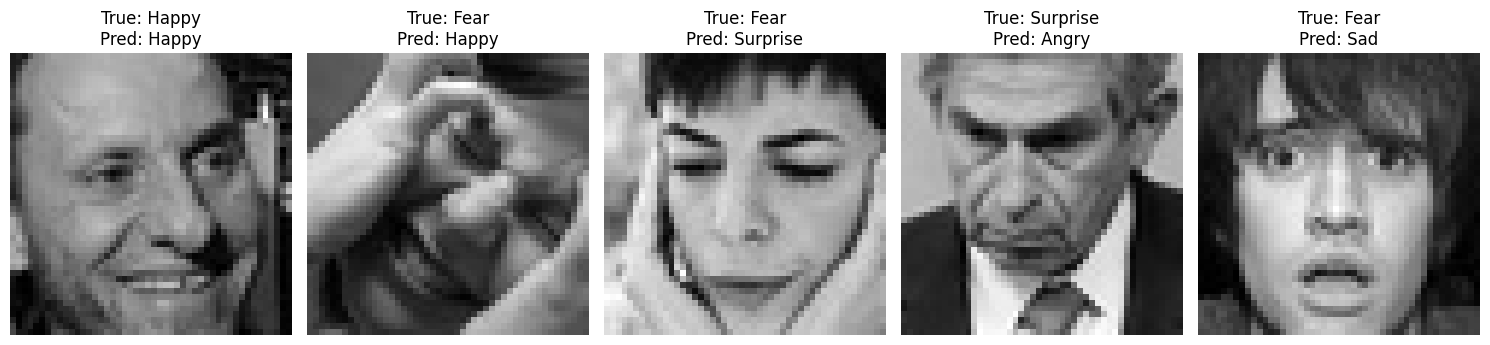

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure emotion_labels is defined
try:
    emotion_labels
except NameError:
    emotion_labels = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

# Select 5 random samples from the validation set
indices = np.random.choice(range(X_val.shape[0]), size=5, replace=False)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    img = X_val[idx].squeeze()  # shape (48,48)
    pred = model.predict(X_val[idx:idx+1])
    pred_label = emotion_labels[np.argmax(pred)]
    true_label = emotion_labels[np.argmax(y_val[idx])]

    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
model.save("emotion_model.h5")

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


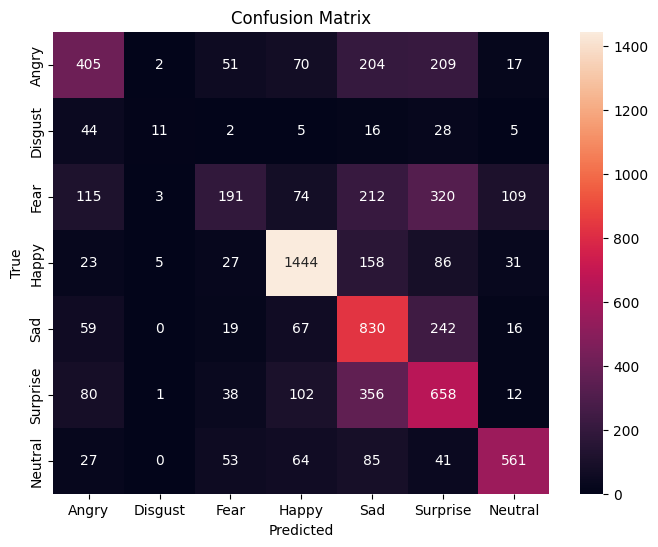

              precision    recall  f1-score   support

       Angry       0.54      0.42      0.47       958
     Disgust       0.50      0.10      0.17       111
        Fear       0.50      0.19      0.27      1024
       Happy       0.79      0.81      0.80      1774
         Sad       0.45      0.67      0.54      1233
    Surprise       0.42      0.53      0.46      1247
     Neutral       0.75      0.68      0.71       831

    accuracy                           0.57      7178
   macro avg       0.56      0.49      0.49      7178
weighted avg       0.58      0.57      0.56      7178



In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=emotion_labels))

In [32]:
!pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 9.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [seaborn]m1/3 [scikit-learn]
